![QuantConnect Logo](https://cdn.quantconnect.com/web/i/icon.png)
<hr>

<Axes: >

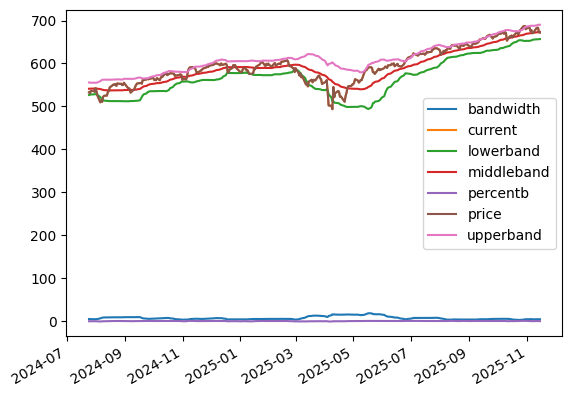

In [1]:
# QuantBook Analysis Tool
# For more information see [https://www.quantconnect.com/docs/v2/our-platform/research/getting-started]
qb = QuantBook()
spy = qb.add_equity("SPY")
history = qb.history(qb.securities.keys(), 360, Resolution.DAILY)

# Indicator Analysis
bbdf = qb.indicator(BollingerBands(30, 2), spy.symbol, 360, Resolution.DAILY)
bbdf.drop('standarddeviation', axis=1).plot()

range detection

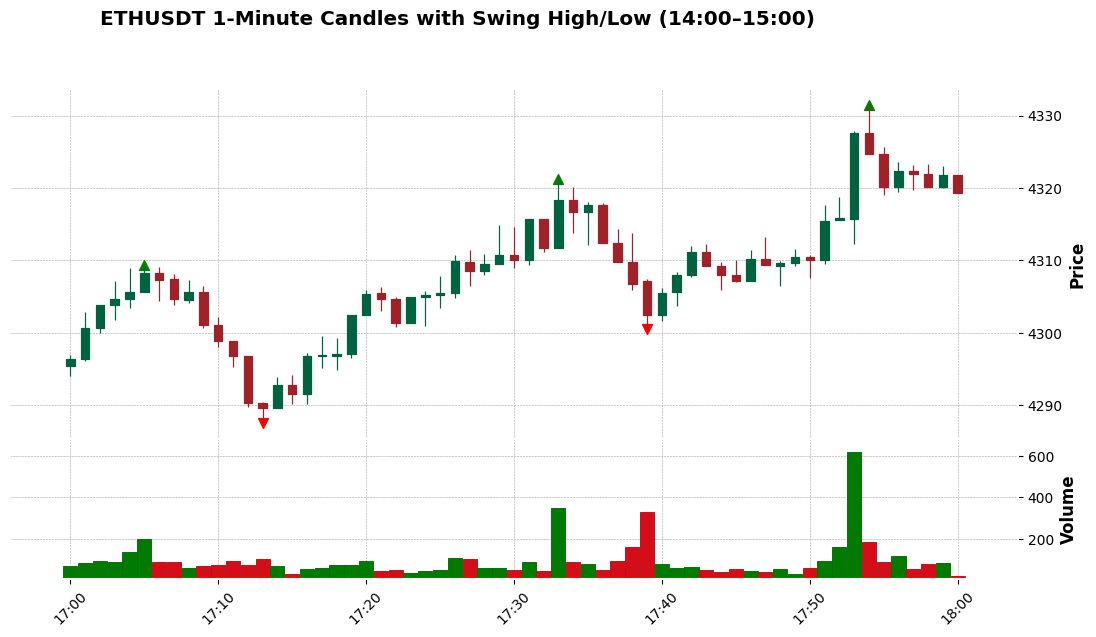

In [ ]:
from AlgorithmImports import *
import pandas as pd
import numpy as np
import mplfinance as mpf
from datetime import datetime

# ⚠️ Импортируем нашу функцию свингов из проекта
# В QC файлы сливаются в один неймспейс, так что достаточно:
from Range_rebuilder import find_swings  # если имя другое — подставь своё

qc = QuantBook()

# === Загружаем ETHUSDT с Bybit ===
symbol = qc.AddCrypto("ETHUSDT", Resolution.Minute, Market.Bybit).Symbol

# === История за выбранный диапазон (с 1 по 3 сентября 2025) ===
start_date = datetime(2025, 9, 2)
end_date   = datetime(2025, 9, 3)
history = qc.History([symbol], start_date, end_date, Resolution.Minute)

# === Преобразуем в DataFrame ===
if isinstance(history.index, pd.MultiIndex):
    history = history.reset_index(level=0, drop=True)

ohlc = history[['open', 'high', 'low', 'close', 'volume']].astype(float)
ohlc.index = pd.to_datetime(ohlc.index)

# Наш find_swings в Range_(re)builder работает с колонками 'High'/'Low'
ohlc_for_swings = ohlc.rename(
    columns={
        'open': 'Open',
        'high': 'High',
        'low': 'Low',
        'close': 'Close'
    }
)

# === Используем наш find_swings из Range_(re)builder ===
# window подставь тот, который у тебя в алгоритме (например, 21)
high_idx, low_idx = find_swings(ohlc_for_swings, window=10)

# Собираем такой же DataFrame, как раньше делал swing_highs_lows
swings = pd.DataFrame(index=ohlc_for_swings.index, columns=["HighLow", "Level"], dtype=float)
swings["HighLow"] = np.nan
swings["Level"] = np.nan

# проставляем swing highs
for i in high_idx:
    ts = ohlc_for_swings.index[i]
    swings.at[ts, "HighLow"] = 1
    swings.at[ts, "Level"] = ohlc_for_swings.at[ts, "High"]

# проставляем swing lows
for i in low_idx:
    ts = ohlc_for_swings.index[i]
    swings.at[ts, "HighLow"] = -1
    swings.at[ts, "Level"] = ohlc_for_swings.at[ts, "Low"]

# === Фильтруем по времени (12:00–15:00) ===
ohlc_workhours = ohlc.between_time('17:00', '18:00')
swings_workhours = swings.loc[ohlc_workhours.index]

swing_high = swings_workhours['Level'].where(swings_workhours['HighLow'] == 1)
swing_low  = swings_workhours['Level'].where(swings_workhours['HighLow'] == -1)

# === Визуализация ===
ap = [
    mpf.make_addplot(swing_high, type='scatter', markersize=50, marker='^', color='green'),
    mpf.make_addplot(swing_low,  type='scatter', markersize=50, marker='v', color='red')
]

mpf.plot(
    ohlc_workhours,
    type='candle',
    style='charles',
    addplot=ap,
    title="ETHUSDT 1-Minute Candles with Swing High/Low (14:00–15:00)",
    volume=True,
    figsize=(14, 7)
)
